# YOLOv8m Fine-Tuning — KITTI Object Detection
**ECE228 | Scene Reconstruction for Autonomous Driving**

Execution order:
1. Environment — pin numpy, install dependencies
2. Configuration — all paths and hyperparameters in one cell
3. GPU verification and Drive mount
4. Dataset — download KITTI, filter to 3 classes, write YAML
5. Training — fine-tune YOLOv8m from COCO pretrained weights
6. Evaluation — mAP@50, mAP@50:95, per-class AP on validation set
7. Compare to Pretrained Baseline

Runtime requirement: GPU (T4 or better). Runtime > Change runtime type > GPU.

---
## 1. Environment Setup

Pin numpy to 1.26.4 before importing ultralytics.
Colab ships numpy 2.x which is binary-incompatible with the version of ultralytics
compiled against numpy 1.x C headers.

After this cell completes: **Runtime > Restart session**, then run from Cell 2 onward.
Do not run any other cells before restarting.

In [ ]:
import subprocess, sys

subprocess.run(
    [sys.executable, '-m', 'pip', 'install', '-q',
     'numpy==1.26.4', '--force-reinstall'],
    check=True
)
subprocess.run(
    [sys.executable, '-m', 'pip', 'install', '-q',
     'ultralytics>=8.3.225', 'opencv-python-headless',
     'matplotlib', 'pandas', '--upgrade'],
    check=True
)

print('Packages installed.')
print('ACTION REQUIRED: Runtime > Restart session, then continue from Cell 2.')

Packages installed.
ACTION REQUIRED: Runtime > Restart session, then continue from Cell 2.


---
## 2. Configuration

All paths and hyperparameters are defined here.
No hard-coded strings appear in later cells.

In [ ]:
# ---------------------------------------------------------------------------
# Paths
# ---------------------------------------------------------------------------
DRIVE_PROJECT_DIR = '/content/drive/MyDrive/ECE228_SceneRecon'
DRIVE_CKPT_DIR    = f'{DRIVE_PROJECT_DIR}/checkpoints'
DRIVE_LOG_DIR     = f'{DRIVE_PROJECT_DIR}/logs'

DATASET_DIR       = '/content/datasets'           # root after KITTI zip extraction
YAML_PATH         = '/content/kitti_3class.yaml'  # written in Cell 4

# ---------------------------------------------------------------------------
# Run identity
# ---------------------------------------------------------------------------
PROJECT_NAME  = 'yolov8m_kitti'
MODEL_WEIGHTS = 'yolov8m.pt'       # COCO pretrained checkpoint

# ---------------------------------------------------------------------------
# Training hyperparameters
# Rationale:
#   imgsz=640     standard input size; increase to 1280 for small-object recall
#   SGD + cosine  standard YOLO training regime, outperforms Adam on detection
#   degrees=0     driving scenes are always upright
#   flipud=0      cars do not appear inverted
#   close_mosaic  disabling mosaic in the final 10 epochs stabilises convergence
# ---------------------------------------------------------------------------
TRAIN_CFG = dict(
    data          = YAML_PATH,
    imgsz         = 640,
    epochs        = 50,
    patience      = 15,
    warmup_epochs = 3,
    optimizer     = 'SGD',
    lr0           = 0.01,
    lrf           = 0.01,
    momentum      = 0.937,
    weight_decay  = 0.0005,
    batch         = 16,
    workers       = 4,
    device        = 0,
    amp           = True,
    mosaic        = 1.0,
    mixup         = 0.1,
    hsv_h         = 0.015,
    hsv_s         = 0.7,
    hsv_v         = 0.4,
    degrees       = 0.0,
    translate     = 0.1,
    scale         = 0.5,
    fliplr        = 0.5,
    flipud        = 0.0,
    perspective   = 0.0,
    close_mosaic  = 10,
    project       = DRIVE_CKPT_DIR,
    name          = PROJECT_NAME,
    save_period   = 5,
    exist_ok      = True,
    plots         = True,
    verbose       = True,
)

# ---------------------------------------------------------------------------
# Evaluation hyperparameters
# conf=0.001 sweeps the full precision-recall curve for accurate mAP
# ---------------------------------------------------------------------------
VAL_CFG = dict(
    data    = YAML_PATH,
    imgsz   = 640,
    batch   = 16,
    conf    = 0.001,
    iou     = 0.6,
    device  = 0,
    verbose = True,
)

# ---------------------------------------------------------------------------
# Class map — Ultralytics KITTI zip has 8 classes (0-7); we keep 0-2
# ---------------------------------------------------------------------------
CLASS_NAMES = {0: 'Car', 1: 'Pedestrian', 2: 'Cyclist'}
TARGET_IDS  = set(CLASS_NAMES.keys())

print('Configuration loaded.')
print(f'  Checkpoint directory : {DRIVE_CKPT_DIR}/{PROJECT_NAME}')
print(f'  Dataset directory    : {DATASET_DIR}')
print(f'  Epochs               : {TRAIN_CFG["epochs"]}')
print(f'  Batch size           : {TRAIN_CFG["batch"]}')
print(f'  Image size           : {TRAIN_CFG["imgsz"]}')

Configuration loaded.
  Checkpoint directory : /content/drive/MyDrive/ECE228_SceneRecon/checkpoints/yolov8m_kitti
  Dataset directory    : /content/datasets
  Epochs               : 50
  Batch size           : 16
  Image size           : 640


---
## 3. GPU Verification and Drive Mount

In [ ]:
import torch, os
from google.colab import drive

if not torch.cuda.is_available():
    raise RuntimeError(
        'No GPU detected. Go to Runtime > Change runtime type > T4 GPU.'
    )

print(f'PyTorch : {torch.__version__}')
print(f'CUDA    : {torch.version.cuda}')
print(f'Device  : {torch.cuda.get_device_name(0)}')
print(f'VRAM    : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

drive.mount('/content/drive')

for d in [DRIVE_CKPT_DIR, DRIVE_LOG_DIR]:
    os.makedirs(d, exist_ok=True)

print(f'Drive mounted.')
print(f'  Checkpoints : {DRIVE_CKPT_DIR}')
print(f'  Logs        : {DRIVE_LOG_DIR}')

PyTorch : 2.10.0+cu128
CUDA    : 12.8
Device  : Tesla T4
VRAM    : 15.6 GB
Mounted at /content/drive
Drive mounted.
  Checkpoints : /content/drive/MyDrive/ECE228_SceneRecon/checkpoints
  Logs        : /content/drive/MyDrive/ECE228_SceneRecon/logs


---
## 4. Dataset Download and Preparation

Downloads the Ultralytics-managed KITTI zip (~372 MB).  
Labels are pre-converted to YOLO format (normalised cx cy w h) but include
8 classes. Annotations for classes 3-7 are stripped so training targets
only Car (0), Pedestrian (1), and Cyclist (2).

In [ ]:
import os, zipfile, subprocess, glob

KITTI_ZIP = '/content/kitti.zip'

# ------------------------------------------------------------------
# Download
# ------------------------------------------------------------------
if not os.path.exists(f'{DATASET_DIR}/images/train'):
    print('Downloading KITTI dataset (~372 MB) ...')
    ret = subprocess.run(
        ['wget', '-q', '--show-progress', '--tries=3', '--timeout=60',
         'https://ultralytics.com/assets/kitti.zip', '-O', KITTI_ZIP],
        check=False
    )
    if ret.returncode != 0:
        raise RuntimeError('wget failed. Check network connectivity.')

    with open(KITTI_ZIP, 'rb') as f:
        magic = f.read(4)
    if magic != b'PK\x03\x04':
        with open(KITTI_ZIP, 'rb') as f:
            preview = f.read(500).decode('utf-8', errors='replace')
        raise RuntimeError(
            f'Downloaded file is not a valid zip. Server response:\n{preview}'
        )

    print('Extracting ...')
    os.makedirs('/content/datasets', exist_ok=True)
    with zipfile.ZipFile(KITTI_ZIP, 'r') as z:
        z.extractall('/content/datasets/')
    os.remove(KITTI_ZIP)
    print('Extraction complete.')
else:
    print('Dataset already present, skipping download.')

# ------------------------------------------------------------------
# Verify structure
# ------------------------------------------------------------------
for split in ['train', 'val']:
    img_dir = f'{DATASET_DIR}/images/{split}'
    lbl_dir = f'{DATASET_DIR}/labels/{split}'
    if not os.path.exists(img_dir):
        raise FileNotFoundError(
            f'Expected directory not found: {img_dir}\n'
            f'Inspect /content/datasets/ to find the actual extraction path.'
        )
    n_img = len(os.listdir(img_dir))
    n_lbl = len(os.listdir(lbl_dir))
    print(f'  {split:5s} : {n_img:,} images | {n_lbl:,} labels')

# ------------------------------------------------------------------
# Filter labels to TARGET_IDS
# Lines with class ids outside {0, 1, 2} cause 'label class exceeds nc'
# warnings during training. Removing them here eliminates the noise.
# ------------------------------------------------------------------
def filter_labels(label_dir, target_ids):
    """Strip annotation lines whose class id is not in target_ids.
    Modifies label files in-place. Returns (total_files, modified_count)."""
    files    = glob.glob(f'{label_dir}/*.txt')
    modified = 0
    for path in files:
        with open(path) as fh:
            lines = fh.readlines()
        kept = [
            line for line in lines
            if len(line.strip().split()) == 5
            and int(line.strip().split()[0]) in target_ids
        ]
        if len(kept) != len(lines):
            with open(path, 'w') as fh:
                fh.writelines(kept)
            modified += 1
    return len(files), modified

print('Filtering labels to classes 0, 1, 2 ...')
for split in ['train', 'val']:
    total, modified = filter_labels(
        f'{DATASET_DIR}/labels/{split}', TARGET_IDS
    )
    print(f'  {split:5s} : {total:,} files | {modified:,} modified')

# ------------------------------------------------------------------
# Write dataset YAML
# ------------------------------------------------------------------
with open(YAML_PATH, 'w') as fh:
    fh.write(
        f'# KITTI 3-class detection — Car (0), Pedestrian (1), Cyclist (2)\n'
        f'path: {DATASET_DIR}\n'
        f'train: images/train\n'
        f'val:   images/val\n'
        f'nc: 3\n'
        f'names:\n'
        f'  0: Car\n'
        f'  1: Pedestrian\n'
        f'  2: Cyclist\n'
    )

print(f'Dataset YAML written to {YAML_PATH}')

Extracting ...
Extraction complete.
  train : 5,985 images | 5,985 labels
  val   : 1,496 images | 1,496 labels
Filtering labels to classes 0, 1, 2 ...
  train : 5,985 files | 2,634 modified
  val   : 1,496 files | 707 modified
Dataset YAML written to /content/kitti_3class.yaml


---
## 5. Training

Fine-tunes YOLOv8m from COCO pretrained weights on the KITTI 3-class dataset.
Model checkpoints are written directly to Google Drive via `project=DRIVE_CKPT_DIR`.

Expected wall-clock time on T4: ~2.5-3.5 hours for 50 epochs at imgsz=640.

To resume an interrupted run, set `RESUME = True`.

In [ ]:
from ultralytics import YOLO
import os

RESUME    = False
last_ckpt = f'{DRIVE_CKPT_DIR}/{PROJECT_NAME}/weights/last.pt'
best_ckpt = f'{DRIVE_CKPT_DIR}/{PROJECT_NAME}/weights/best.pt'

if RESUME and os.path.exists(last_ckpt):
    print(f'Resuming from {last_ckpt}')
    model   = YOLO(last_ckpt)
    results = model.train(resume=True)
else:
    if RESUME:
        print('No checkpoint found for resume. Starting from pretrained weights.')
    print(f'Loading pretrained weights: {MODEL_WEIGHTS}')
    model   = YOLO(MODEL_WEIGHTS)
    print(f'Parameters: {sum(p.numel() for p in model.model.parameters()):,}')
    results = model.train(**TRAIN_CFG)

print('Training complete.')
print(f'  Best checkpoint : {best_ckpt}')
print(f'  Last checkpoint : {last_ckpt}')

Loading pretrained weights: yolov8m.pt
Parameters: 25,902,640
Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/kitti_3class.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8m_kitti, nbs=64, nms=False, opset=None, o

---
## 6. Evaluation

Evaluates the best checkpoint on the validation split.
Reports overall and per-class AP at IoU thresholds 0.50 and 0.50:0.95.

In [ ]:
from ultralytics import YOLO
import os

# Redefine best_ckpt and last_ckpt as they might be cleared after a runtime restart
best_ckpt = f'{DRIVE_CKPT_DIR}/{PROJECT_NAME}/weights/best.pt'
last_ckpt = f'{DRIVE_CKPT_DIR}/{PROJECT_NAME}/weights/last.pt' # Not strictly needed in this cell, but good for consistency

print(f'Loading checkpoint: {best_ckpt}')
eval_model = YOLO(best_ckpt)
metrics    = eval_model.val(**VAL_CFG)

sep = '-' * 52
print(sep)
print('VALIDATION RESULTS')
print(sep)
print(f'  mAP@50       : {metrics.box.map50:.4f}   (target >= 0.50)')
print(f'  mAP@50:95    : {metrics.box.map:.4f}')
print(f'  Precision    : {metrics.box.mp:.4f}')
print(f'  Recall       : {metrics.box.mr:.4f}')
print(sep)
print('  Per-class AP@50:')
for i, name in CLASS_NAMES.items():
    ap50 = metrics.box.ap50[i] if i < len(metrics.box.ap50) else float('nan')
    print(f'    {name:<14} {ap50:.4f}')
print(sep)
print('Benchmark gates:')
print(f'  Car mAP@50 >= 0.70     : {"PASS" if metrics.box.ap50[0] >= 0.70 else "FAIL"}')
print(f'  Overall mAP@50 >= 0.50 : {"PASS" if metrics.box.map50 >= 0.50 else "FAIL"}')
print(sep)


Loading checkpoint: /content/drive/MyDrive/ECE228_SceneRecon/checkpoints/yolov8m_kitti/weights/best.pt
Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 93 layers, 25,841,497 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1609.5±836.1 MB/s, size: 56.9 KB)
val: Scanning /content/datasets/labels/val... 1496 images, 154 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1496/1496 2.3Kit/s 0.7s
val: New cache created: /content/datasets/labels/val.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 94/94 5.4it/s 17.6s
                   all       1496       6494      0.961      0.936      0.973      0.839
                   Car       1322       5716      0.954       0.94      0.976      0.839
            Pedestrian        419        555      0.955      0.926      0.965      0.819
               Cyclist        212        223      0.972      0.94

# 7. Compare to Pretrained Baseline

In [ ]:
from torchmetrics.detection.mean_ap import MeanAveragePrecision
from pathlib import Path
from PIL import Image
import torch
from ultralytics import YOLO

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
base = YOLO("yolov8m.pt")

KITTI_IMAGES = Path("/content/datasets/kitti/images/val")
KITTI_LABELS = Path("/content/datasets/kitti/labels/val")

# Need to remap to fit KITTI dataset
COCO_TO_KITTI = {2: 0, 0: 1, 1: 2}

metric = MeanAveragePrecision(iou_thresholds=[0.5], class_metrics=True)

for img_path in sorted(KITTI_IMAGES.glob("*.png")):
  label_path = KITTI_LABELS / img_path.with_suffix('.txt').name
  if not label_path.exists():
    continue

  W, H = Image.open(img_path).size

  # Ground truth: Car=0, Pedestrian=3, Cyclist=5 in original KITTI labels
  KITTI_GT = {0: 0, 3: 1, 5: 2}
  gt_boxes, gt_labels = [], []
  with open(label_path) as f:
    for line in f:
      p = line.strip().split()
      if p and int(p[0]) in KITTI_GT:
        cx, cy, w, h = float(p[1])*W, float(p[2])*H, float(p[3])*W, float(p[4])*H
        gt_boxes.append([cx-w/2, cy-h/2, cx+w/2, cy+h/2])
        gt_labels.append(KITTI_GT[int(p[0])])
  if not gt_boxes:
    continue

  r = base.predict(str(img_path), imgsz=640, conf=0.25, device=DEVICE, verbose=False)[0]
  pred_boxes, pred_scores, pred_labels = [], [], []
  for box, score, cls in zip(r.boxes.xyxy.cpu(), r.boxes.conf.cpu(), r.boxes.cls.cpu().int().tolist()):
    if cls in COCO_TO_KITTI:
      pred_boxes.append(box.tolist())
      pred_scores.append(score.item())
      pred_labels.append(COCO_TO_KITTI[cls])

  metric.update(
    [{"boxes":  torch.tensor(pred_boxes).reshape(-1, 4) if pred_boxes else torch.zeros((0,4)),
      "scores": torch.tensor(pred_scores),
      "labels": torch.tensor(pred_labels, dtype=torch.int64)}],
    [{"boxes":  torch.tensor(gt_boxes, dtype=torch.float32),
      "labels": torch.tensor(gt_labels, dtype=torch.int64)}]
  )

results = metric.compute()
CLASS_NAMES = {0: 'Car', 1: 'Pedestrian', 2: 'Cyclist'}

print(f"mAP@50:    {results['map_50'].item():.4f}")
print(f"mAP@50-95: {results['map'].item():.4f}")
print()
print(f"  {'Class':20s} {'AP@50':>10}")
for i, ap in enumerate(results['map_per_class']):
    print(f"  {CLASS_NAMES.get(i, f'class_{i}'):20s} {ap.item():>10.4f}")

mAP@50:    0.3991
mAP@50-95: 0.3991

  Class                     AP@50
  Car                      0.7513
  Pedestrian               0.4444
  Cyclist                  0.0017


## Visualize Improvement of FineTuning

/tmp/ipykernel_10032/1596578349.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=9)


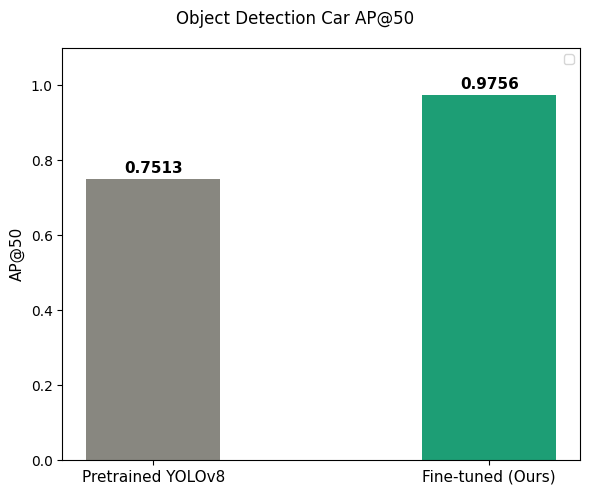

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

models  = ['Pretrained YOLOv8', 'Fine-tuned (Ours)']
colors  = ['#888780', '#1D9E75']

car_ap = [0.7513, 0.9756]

x = np.arange(len(models))
width = 0.4

fig, ax = plt.subplots(figsize=(6, 5))
fig.suptitle('Object Detection Car AP@50', fontsize=12)

bars = ax.bar(x, car_ap, width, color=colors)

for bar, v in zip(bars, car_ap):
  ax.text(bar.get_x() + bar.get_width()/2, v + 0.008, f'{v:.4f}',
          ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_ylabel('AP@50', fontsize=11)
ax.set_ylim(0, 1.1)
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=11)
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('car_ap_comparison.png', dpi=150, bbox_inches='tight')
plt.show()